# 1.1 — LLM serving metrics & batching (real vLLM)

```text
1 metrics → 2 load → 3 concurrency → 4 prompt length
→ 5 static / dynamic / continuous (+ timelines)
→ 6 chunked prefill (rider vs freighter)
```


## 1 — Metrics (what / why)

```text
send ──[ TTFT ≈ prefill ]── first token ──[ decode ]── last token
|<------------------------ e2e ------------------------------>|
                    TPOT = avg gap between later tokens
```

| Metric | Meaning | Watch it when… |
|--------|---------|----------------|
| **TTFT** | time to first token | prompt gets longer, or requests queue |
| **TPOT** | time per output token (after first) | batch gets wider |
| **e2e** | send → last token | overall latency SLO |
| **tok/s** | output tokens / wall time | did batching fill the GPU? |

## 2 — Load engine

In [1]:
import asyncio
import sys
import time
import uuid
from dataclasses import dataclass
from pathlib import Path
from statistics import mean, median

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from transformers import AutoTokenizer
from vllm import SamplingParams
from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.engine.async_llm_engine import AsyncLLMEngine

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "local_paths.py").is_file():
        sys.path.insert(0, str(p))
        break

from local_paths import model_path

MODEL = str(model_path("QWEN_MODEL"))
print("MODEL =", MODEL)

engine = AsyncLLMEngine.from_engine_args(
    AsyncEngineArgs(
        model=MODEL,
        dtype="float16",
        gpu_memory_utilization=0.85,
        max_model_len=1024,
        max_num_seqs=4,
        enforce_eager=True,
        disable_log_requests=True,
    )
)
tok = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True, local_files_only=True)
print("engine ready  |  max_num_seqs=4")

/home/mbrdiuser/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-24 19:33:25,152	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


MODEL = /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct
WARNING 09-24 19:33:26 config.py:1657] Casting torch.bfloat16 to torch.float16.
WARNING 09-24 19:33:26 config.py:383] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 09-24 19:33:26 llm_engine.py:223] Initializing an LLM engine (v0.6.1.post1) with config: model='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=1024, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, kv_cache_dtype=au

/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


INFO 09-24 19:33:29 model_runner.py:997] Starting to load model /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct...
INFO 09-24 19:33:29 selector.py:217] Cannot use FlashAttention-2 backend for Volta and Turing GPUs.
INFO 09-24 19:33:29 selector.py:116] Using XFormers backend.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.31it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  3.30it/s]



INFO 09-24 19:33:29 model_runner.py:1008] Loading model weights took 0.9276 GB
INFO 09-24 19:33:30 gpu_executor.py:122] # GPU blocks: 16699, # CPU blocks: 21845
engine ready  |  max_num_seqs=4


In [2]:
async def generate_one(prompt: str, max_tokens: int = 20) -> dict:
    """Real vLLM stream → TTFT / TPOT / e2e / decode."""
    sp = SamplingParams(temperature=0.0, max_tokens=max_tokens)
    rid = uuid.uuid4().hex
    t_send = time.perf_counter()
    times: list[float] = []
    text = ""

    async for out in engine.generate(prompt, sp, rid):
        n = len(out.outputs[0].token_ids)
        now = time.perf_counter()
        while len(times) < n:
            times.append(now)
        text = out.outputs[0].text

    n = len(times)
    gaps = [times[i] - times[i - 1] for i in range(1, n)]
    return {
        "ok": n > 0,
        "n_tok": n,
        "ttft_s": (times[0] - t_send) if n else None,
        "tpot_s": mean(gaps) if gaps else None,
        "decode_s": (times[-1] - times[0]) if n >= 2 else (0.0 if n == 1 else None),
        "e2e_s": (times[-1] - t_send) if n else None,
        "t_send": t_send,
        "t_first": times[0] if times else None,
        "t_last": times[-1] if times else None,
        "text": text,
    }


m = await generate_one("The capital of France is", max_tokens=8)
print(
    f"tok={m['n_tok']}  TTFT={m['ttft_s']:.3f}s  TPOT={m['tpot_s']:.4f}s  "
    f"decode={m['decode_s']:.3f}s  e2e={m['e2e_s']:.3f}s"
)
print(m["text"])

tok=8  TTFT=0.066s  TPOT=0.0176s  decode=0.123s  e2e=0.189s
 Paris. It is the largest city in


## 3 — Concurrency (how many requests at once)

Fire N identical prompts together. Seats = `max_num_seqs=4`.

| Expect | Why |
|--------|-----|
| tok/s rises until ~4, then flattens | seats full |
| TTFT jumps past 4 | extras wait in queue |
| TPOT rises a little then flat | wider batch = heavier decode step |

n= 1  TTFT=0.028s  TPOT=0.0147s  e2e=0.307s  tok/s=65.2
n= 2  TTFT=0.033s  TPOT=0.0148s  e2e=0.315s  tok/s=127.1
n= 4  TTFT=0.030s  TPOT=0.0161s  e2e=0.336s  tok/s=238.0
n= 8  TTFT=0.195s  TPOT=0.0156s  e2e=0.491s  tok/s=245.0
n=16  TTFT=0.522s  TPOT=0.0156s  e2e=0.818s  tok/s=243.1


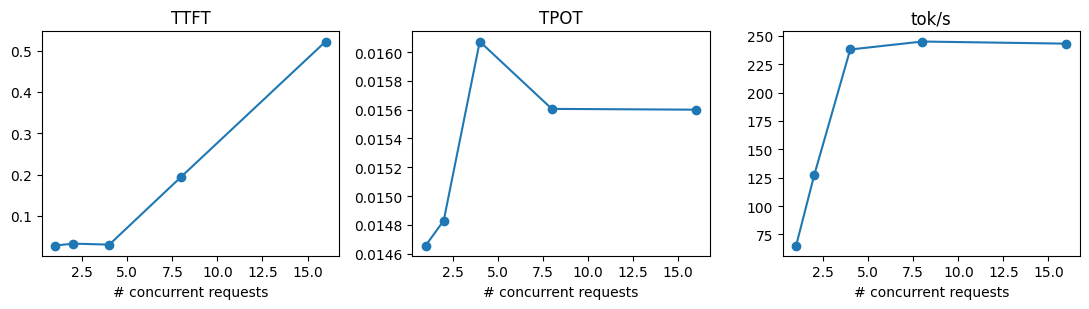

In [3]:
PROMPT = "Explain KV cache in one short paragraph."
await generate_one(PROMPT, 20)  # warmup

rows_conc = []
for n in (1, 2, 4, 8, 16):
    prompts = [f"{PROMPT} [{i}]" for i in range(n)]
    results = await asyncio.gather(*[generate_one(p, 20) for p in prompts])
    ok = [r for r in results if r["ok"]]
    wall = max(r["t_last"] for r in ok) - min(r["t_send"] for r in results)
    row = {
        "n": n,
        "ttft_p50": median(r["ttft_s"] for r in ok),
        "tpot_p50": median(r["tpot_s"] for r in ok if r["tpot_s"] is not None),
        "e2e_p50": median(r["e2e_s"] for r in ok),
        "tok_s": sum(r["n_tok"] for r in ok) / wall,
    }
    rows_conc.append(row)
    print(
        f"n={n:2d}  TTFT={row['ttft_p50']:.3f}s  TPOT={row['tpot_p50']:.4f}s  "
        f"e2e={row['e2e_p50']:.3f}s  tok/s={row['tok_s']:.1f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
xs = [r["n"] for r in rows_conc]
axes[0].plot(xs, [r["ttft_p50"] for r in rows_conc], marker="o")
axes[0].set_title("TTFT"); axes[0].set_xlabel("# concurrent requests")
axes[1].plot(xs, [r["tpot_p50"] for r in rows_conc], marker="o")
axes[1].set_title("TPOT"); axes[1].set_xlabel("# concurrent requests")
axes[2].plot(xs, [r["tok_s"] for r in rows_conc], marker="o")
axes[2].set_title("tok/s"); axes[2].set_xlabel("# concurrent requests")
plt.tight_layout(); plt.show()

## 4 — Prompt length (prefill → TTFT)

One request at a time. Grow prompt tokens (real tokenizer). Decode stays ~20 tokens.

| Expect | Why |
|--------|-----|
| TTFT rises with prompt length | more prefill work |
| TPOT / decode stay roughly flat | same ~20 output tokens |

prompt sizes:
  target=  64 → measured=  64 tokens
  target= 128 → measured= 128 tokens
  target= 256 → measured= 255 tokens
  target= 512 → measured= 511 tokens
  target= 768 → measured= 768 tokens
  target= 900 → measured= 900 tokens
prompt=  64 tok  TTFT=0.028s  TPOT=0.0146s  decode=0.278s
prompt= 128 tok  TTFT=0.029s  TPOT=0.0147s  decode=0.279s
prompt= 255 tok  TTFT=0.031s  TPOT=0.0146s  decode=0.277s
prompt= 511 tok  TTFT=0.033s  TPOT=0.0153s  decode=0.290s
prompt= 768 tok  TTFT=0.034s  TPOT=0.0154s  decode=0.293s
prompt= 900 tok  TTFT=0.036s  TPOT=0.0152s  decode=0.288s


INFO 09-24 19:33:38 metrics.py:351] Avg prompt throughput: 105.1 tokens/s, Avg generation throughput: 137.0 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 09-24 19:33:43 metrics.py:351] Avg prompt throughput: 654.9 tokens/s, Avg generation throughput: 63.5 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.2%, CPU KV cache usage: 0.0%.
INFO 09-24 19:33:48 metrics.py:351] Avg prompt throughput: 1977.9 tokens/s, Avg generation throughput: 52.7 tokens/s, Running: 1 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.
INFO 09-24 19:33:53 metrics.py:351] Avg prompt throughput: 33.8 tokens/s, Avg generation throughput: 66.9 tokens/s, Running: 2 reqs, Swapped: 0 reqs, Pending: 0 reqs, GPU KV cache usage: 0.0%, CPU KV cache usage: 0.0%.


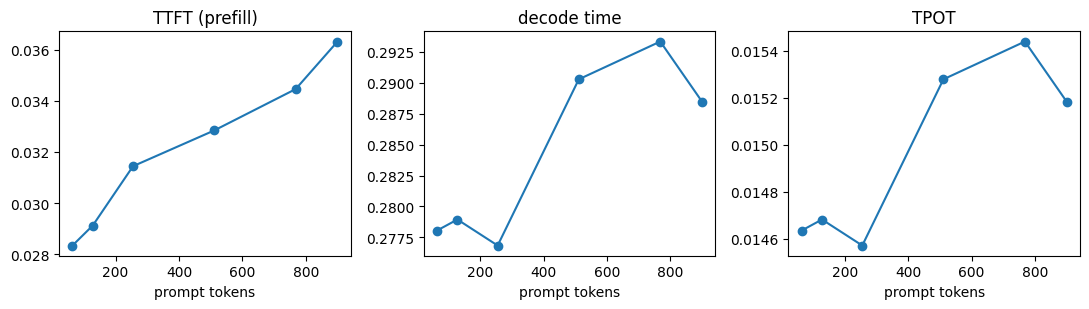

In [4]:
FILLER = (
    "The quick brown fox studies attention, KV cache, continuous batching, "
    "prefill cost, and decode latency on a single GPU serving stack. "
)


def count_tokens(text: str) -> int:
    return len(tok.encode(text, add_special_tokens=False))


def make_prompt(target_tokens: int) -> str:
    instruction = "In one short sentence, say what topic this passage discusses.\n\n"
    body = ""
    while count_tokens(instruction + body) < target_tokens:
        body += FILLER
        if len(body) > 500_000:
            break
    text = (instruction + body).strip()
    while count_tokens(text) > target_tokens and len(text) > len(instruction) + 10:
        text = text.rsplit(" ", 1)[0]
    return text


LENGTHS = (64, 128, 256, 512, 768, 900)
REPEATS = 5

print("prompt sizes:")
for n in LENGTHS:
    print(f"  target={n:4d} → measured={count_tokens(make_prompt(n)):4d} tokens")

await generate_one(make_prompt(64), 20)

rows_len = []
for n in LENGTHS:
    prompt = make_prompt(n)
    measured = count_tokens(prompt)
    waves = [await generate_one(f"{prompt}\n[rep={r}]", 20) for r in range(REPEATS)]
    ok = [w for w in waves if w["ok"]]
    row = {
        "prompt_tok": measured,
        "ttft_s": median(w["ttft_s"] for w in ok),
        "tpot_s": median(w["tpot_s"] for w in ok if w["tpot_s"] is not None),
        "decode_s": median(w["decode_s"] for w in ok),
        "e2e_s": median(w["e2e_s"] for w in ok),
    }
    rows_len.append(row)
    print(
        f"prompt={measured:4d} tok  TTFT={row['ttft_s']:.3f}s  "
        f"TPOT={row['tpot_s']:.4f}s  decode={row['decode_s']:.3f}s"
    )

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
xs = [r["prompt_tok"] for r in rows_len]
axes[0].plot(xs, [r["ttft_s"] for r in rows_len], marker="o")
axes[0].set_title("TTFT (prefill)"); axes[0].set_xlabel("prompt tokens")
axes[1].plot(xs, [r["decode_s"] for r in rows_len], marker="o")
axes[1].set_title("decode time"); axes[1].set_xlabel("prompt tokens")
axes[2].plot(xs, [r["tpot_s"] for r in rows_len], marker="o")
axes[2].set_title("TPOT"); axes[2].set_xlabel("prompt tokens")
plt.tight_layout(); plt.show()

## 5 — Static vs dynamic vs continuous

| Policy | Rule in plain words |
|--------|---------------------|
| **Static** | Wait until 4 jobs arrived → run them → **give answers only when the slowest of those 4 is done** → next 4 |
| **Dynamic** | Same, but a group can leave early when a **time window** ends |
| **Continuous** | Start each job when it arrives; **return as soon as it finishes** |

### The 8 jobs

| Name | Kind | Arrives | Output | Role |
|------|------|--------:|-------:|------|
| `quick_1` / `quick_2` | quick | early | 8 tok | short early |
| `essay_1` | essay | early | 48 tok | slow roommate (group 1) |
| `quick_late_1` | quick | late | 8 tok | trapped with essay under closed batch |
| `quick_3` / `quick_4` | quick | mid | 8 tok | second wave |
| `essay_2` | essay | mid | 48 tok | slow roommate (group 2) |
| `quick_late_2` | quick | very late | 8 tok | continuous can sneak in while essay still runs |

In [5]:
@dataclass
class Job:
    name: str
    kind: str
    prompt: str
    arrive_s: float
    max_tokens: int


JOBS = [
    Job("quick_1",      "quick", "One word: color of the sky?", 0.00, 8),
    Job("quick_2",      "quick", "One word: color of grass?", 0.05, 8),
    Job("essay_1",      "essay", "Write a detailed paragraph on KV cache in transformers.", 0.10, 48),
    Job("quick_late_1", "quick", "One word: what is 2+2?", 0.30, 8),
    Job("quick_3",      "quick", "One word: capital of Japan?", 0.80, 8),
    Job("essay_2",      "essay", "Write a detailed paragraph on continuous batching.", 0.85, 48),
    Job("quick_4",      "quick", "One word: capital of Italy?", 0.90, 8),
    Job("quick_late_2", "quick", "One word: what is 3+5?", 1.20, 8),
]

print(f"{'name':14s} {'kind':6s} {'arrive':>7s} {'out':>4s}")
for j in JOBS:
    print(f"{j.name:14s} {j.kind:6s} {j.arrive_s:6.2f}s {j.max_tokens:4d}")


def pack_row(j: Job, m: dict, t0: float, t_release: float) -> dict:
    """All times relative to wave start t0 — for the timeline chart."""
    arrive = j.arrive_s
    start = m["t_send"] - t0
    first = m["t_first"] - t0
    done = m["t_last"] - t0
    release = t_release - t0
    return {
        "name": j.name,
        "kind": j.kind,
        "n_tok": m["n_tok"],
        "arrive": arrive,
        "start": start,          # generate begins
        "first": first,          # first token = end of prefill/TTFT
        "done": done,            # last token = end of decode
        "release": release,      # client gets answer (may be later than done)
        "ttft_s": m["ttft_s"],
        "decode_s": m["decode_s"],
        "e2e_s": release - arrive,  # arrival → answer in hand
    }

name           kind    arrive  out
quick_1        quick    0.00s    8
quick_2        quick    0.05s    8
essay_1        essay    0.10s   48
quick_late_1   quick    0.30s    8
quick_3        quick    0.80s    8
essay_2        essay    0.85s   48
quick_4        quick    0.90s    8
quick_late_2   quick    1.20s    8


### Timeline chart helper

Each row = one prompt. Segments on the time axis:

| Color | Segment | Meaning |
|-------|---------|--------|
| gray | wait | arrived, not started yet |
| blue | prefill | start → first token (TTFT) |
| orange | decode | first → last token |
| red | hold | finished generating, but answer held until closed batch releases |

Black marker `|` = arrival. Full bar span from arrival → release = **e2e**.

In [6]:
COLORS = {
    "wait": "#b0b0b0",
    "prefill": "#4c78a8",   # TTFT
    "decode": "#f58518",
    "hold": "#e45756",
}


def plot_timeline(rows: list[dict], title: str, ax=None):
    """Gantt: y = prompts, x = time. Shows wait / prefill / decode / hold."""
    rows = sorted(rows, key=lambda r: r["arrive"])
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(11, 4.2))

    for i, r in enumerate(rows):
        y = i
        # wait: arrive → start
        if r["start"] > r["arrive"]:
            ax.barh(y, r["start"] - r["arrive"], left=r["arrive"], height=0.55,
                    color=COLORS["wait"], edgecolor="white", linewidth=0.5)
        # prefill: start → first
        ax.barh(y, r["first"] - r["start"], left=r["start"], height=0.55,
                color=COLORS["prefill"], edgecolor="white", linewidth=0.5)
        # decode: first → done
        ax.barh(y, r["done"] - r["first"], left=r["first"], height=0.55,
                color=COLORS["decode"], edgecolor="white", linewidth=0.5)
        # hold: done → release (only if closed batch keeps the answer)
        if r["release"] > r["done"] + 1e-4:
            ax.barh(y, r["release"] - r["done"], left=r["done"], height=0.55,
                    color=COLORS["hold"], edgecolor="white", linewidth=0.5)
        # arrival tick
        ax.plot(r["arrive"], y, marker="|", color="black", markersize=12, markeredgewidth=2)

    ax.set_yticks(range(len(rows)), [r["name"] for r in rows])
    ax.set_xlabel("time (s) from wave start")
    ax.set_title(title)
    ax.set_ylim(-0.7, len(rows) - 0.3)
    ax.grid(axis="x", alpha=0.3)

    if own:
        ax.legend(
            handles=[
                Patch(color=COLORS["wait"], label="wait (arrived, not started)"),
                Patch(color=COLORS["prefill"], label="prefill / TTFT"),
                Patch(color=COLORS["decode"], label="decode"),
                Patch(color=COLORS["hold"], label="hold (waiting for batch mates)"),
            ],
            loc="upper right",
            fontsize=8,
        )
        plt.tight_layout()
        plt.show()

### 5a — Static (closed groups of 4)

[static] start ['quick_1', 'quick_2', 'essay_1', 'quick_late_1']
[static] release ['quick_1', 'quick_2', 'essay_1', 'quick_late_1'] at +1.07s
[static] start ['quick_3', 'essay_2', 'quick_4', 'quick_late_2']
[static] release ['quick_3', 'essay_2', 'quick_4', 'quick_late_2'] at +1.96s
  quick_1         prefill=0.046s  decode=0.126s  e2e=1.072s  hold=0.599s
  quick_2         prefill=0.046s  decode=0.126s  e2e=1.022s  hold=0.599s
  essay_1         prefill=0.046s  decode=0.724s  e2e=0.972s  hold=0.000s
  quick_late_1    prefill=0.046s  decode=0.126s  e2e=0.772s  hold=0.598s
  quick_3         prefill=0.040s  decode=0.122s  e2e=1.157s  hold=0.594s
  essay_2         prefill=0.040s  decode=0.716s  e2e=1.107s  hold=0.000s
  quick_4         prefill=0.040s  decode=0.122s  e2e=1.057s  hold=0.594s
  quick_late_2    prefill=0.040s  decode=0.122s  e2e=0.757s  hold=0.594s


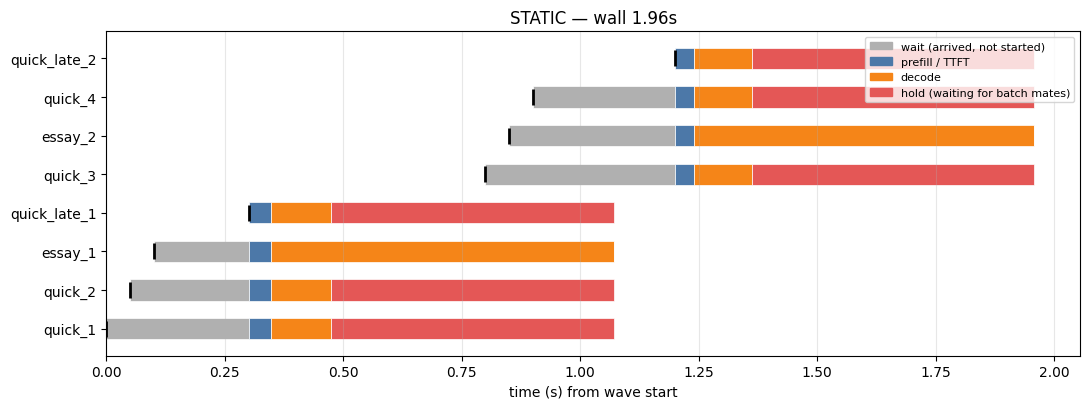

In [7]:
async def run_static(jobs: list[Job], batch_size: int = 4):
    t0 = time.perf_counter()
    pending = sorted(jobs, key=lambda j: j.arrive_s)
    results = []

    for i in range(0, len(pending), batch_size):
        batch = pending[i : i + batch_size]
        delay = t0 + batch[-1].arrive_s - time.perf_counter()
        if delay > 0:
            await asyncio.sleep(delay)

        names = [j.name for j in batch]
        print(f"[static] start {names}")
        outs = await asyncio.gather(
            *[generate_one(j.prompt, j.max_tokens) for j in batch]
        )
        t_release = time.perf_counter()
        print(f"[static] release {names} at +{t_release - t0:.2f}s")
        for j, m in zip(batch, outs):
            results.append(pack_row(j, m, t0, t_release))

    return results, time.perf_counter() - t0


await generate_one(JOBS[0].prompt, 8)
static_rows, static_wall = await run_static(JOBS, batch_size=4)
for r in static_rows:
    print(
        f"  {r['name']:14s}  prefill={r['ttft_s']:.3f}s  decode={r['decode_s']:.3f}s  "
        f"e2e={r['e2e_s']:.3f}s  hold={max(0, r['release']-r['done']):.3f}s"
    )
plot_timeline(static_rows, f"STATIC — wall {static_wall:.2f}s")

### 5b — Dynamic (window=0.25s or full, still closed)

[dynamic] start ['quick_1', 'quick_2', 'essay_1']
[dynamic] release ['quick_1', 'quick_2', 'essay_1'] at +1.02s
[dynamic] start ['quick_late_1', 'quick_3', 'essay_2', 'quick_4']
[dynamic] release ['quick_late_1', 'quick_3', 'essay_2', 'quick_4'] at +1.75s
[dynamic] start ['quick_late_2']
[dynamic] release ['quick_late_2'] at +1.89s
  quick_1         prefill=0.046s  decode=0.123s  e2e=1.023s  hold=0.603s
  quick_2         prefill=0.046s  decode=0.123s  e2e=0.973s  hold=0.603s
  essay_1         prefill=0.046s  decode=0.725s  e2e=0.923s  hold=0.000s
  quick_late_1    prefill=0.033s  decode=0.110s  e2e=1.450s  hold=0.583s
  quick_3         prefill=0.033s  decode=0.110s  e2e=0.950s  hold=0.583s
  essay_2         prefill=0.033s  decode=0.693s  e2e=0.900s  hold=0.000s
  quick_4         prefill=0.033s  decode=0.110s  e2e=0.850s  hold=0.583s
  quick_late_2    prefill=0.031s  decode=0.104s  e2e=0.686s  hold=0.000s


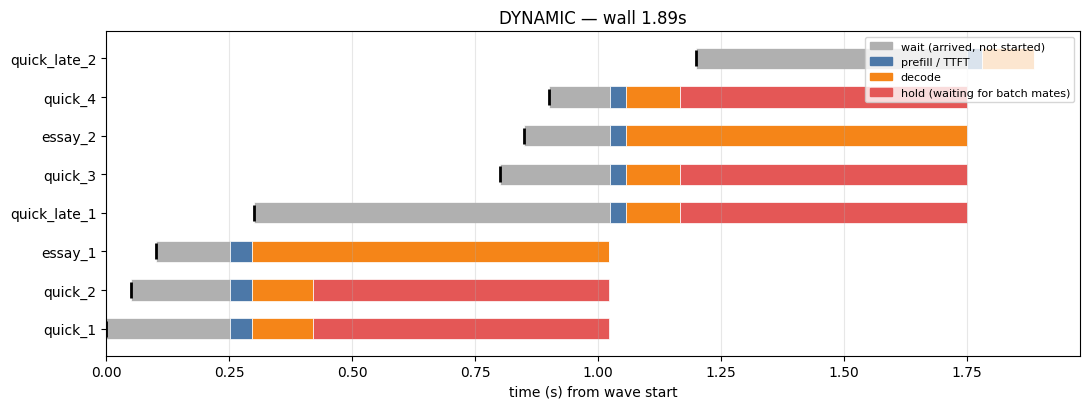

In [8]:
async def run_dynamic(jobs: list[Job], max_batch: int = 4, window_s: float = 0.25):
    t0 = time.perf_counter()
    left = sorted(jobs, key=lambda j: j.arrive_s)
    results = []

    while left:
        delay = t0 + left[0].arrive_s - time.perf_counter()
        if delay > 0:
            await asyncio.sleep(delay)

        deadline = time.perf_counter() + window_s
        batch = [left.pop(0)]
        while left and len(batch) < max_batch:
            now = time.perf_counter()
            if now >= deadline:
                break
            next_at = t0 + left[0].arrive_s
            if next_at > deadline:
                await asyncio.sleep(deadline - now)
                break
            await asyncio.sleep(max(0.0, next_at - now))
            batch.append(left.pop(0))

        names = [j.name for j in batch]
        print(f"[dynamic] start {names}")
        outs = await asyncio.gather(
            *[generate_one(j.prompt, j.max_tokens) for j in batch]
        )
        t_release = time.perf_counter()
        print(f"[dynamic] release {names} at +{t_release - t0:.2f}s")
        for j, m in zip(batch, outs):
            results.append(pack_row(j, m, t0, t_release))

    return results, time.perf_counter() - t0


dynamic_rows, dynamic_wall = await run_dynamic(JOBS, max_batch=4, window_s=0.25)
for r in dynamic_rows:
    print(
        f"  {r['name']:14s}  prefill={r['ttft_s']:.3f}s  decode={r['decode_s']:.3f}s  "
        f"e2e={r['e2e_s']:.3f}s  hold={max(0, r['release']-r['done']):.3f}s"
    )
plot_timeline(dynamic_rows, f"DYNAMIC — wall {dynamic_wall:.2f}s")

### 5c — Continuous (admit on arrival, return when done)

[continuous] start quick_1        at +0.00s
[continuous] start quick_2        at +0.05s
[continuous] start essay_1        at +0.10s
[continuous] done  quick_1        at +0.21s  tok=8
[continuous] done  quick_2        at +0.22s  tok=8
[continuous] start quick_late_1   at +0.30s
[continuous] done  quick_late_1   at +0.45s  tok=8
[continuous] start quick_3        at +0.80s
[continuous] start essay_2        at +0.85s
[continuous] start quick_4        at +0.90s
[continuous] done  essay_1        at +0.92s  tok=48
[continuous] done  quick_3        at +1.01s  tok=8
[continuous] done  quick_4        at +1.05s  tok=8
[continuous] start quick_late_2   at +1.20s
[continuous] done  quick_late_2   at +1.34s  tok=8
[continuous] done  essay_2        at +1.64s  tok=48
  quick_1         prefill=0.039s  decode=0.168s  e2e=0.208s  hold=0.000s
  quick_2         prefill=0.034s  decode=0.139s  e2e=0.174s  hold=0.000s
  essay_1         prefill=0.028s  decode=0.786s  e2e=0.815s  hold=0.000s
  quick_late_1    p

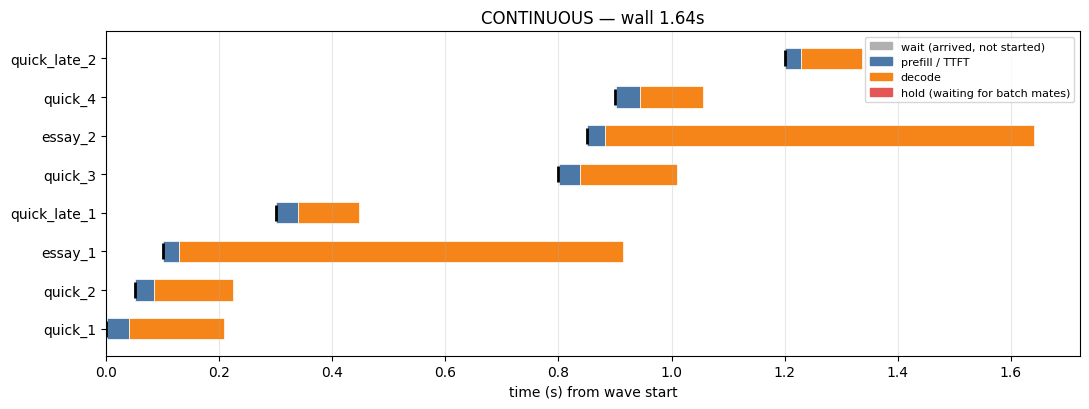

In [9]:
async def run_continuous(jobs: list[Job]):
    t0 = time.perf_counter()

    async def one(j: Job):
        delay = t0 + j.arrive_s - time.perf_counter()
        if delay > 0:
            await asyncio.sleep(delay)
        print(f"[continuous] start {j.name:14s} at +{time.perf_counter() - t0:.2f}s")
        m = await generate_one(j.prompt, j.max_tokens)
        t_done = time.perf_counter()
        print(f"[continuous] done  {j.name:14s} at +{t_done - t0:.2f}s  tok={m['n_tok']}")
        # continuous: release = own stream end (no hold)
        return pack_row(j, m, t0, t_release=m["t_last"])

    results = await asyncio.gather(*[one(j) for j in jobs])
    return list(results), time.perf_counter() - t0


cont_rows, cont_wall = await run_continuous(JOBS)
for r in sorted(cont_rows, key=lambda x: x["arrive"]):
    print(
        f"  {r['name']:14s}  prefill={r['ttft_s']:.3f}s  decode={r['decode_s']:.3f}s  "
        f"e2e={r['e2e_s']:.3f}s  hold={max(0, r['release']-r['done']):.3f}s"
    )
plot_timeline(cont_rows, f"CONTINUOUS — wall {cont_wall:.2f}s")

### 5d — Side-by-side timelines + numbers

Compare the three charts: under static/dynamic, **red hold** on quick jobs = waiting for an essay roommate. Continuous has **no red**.

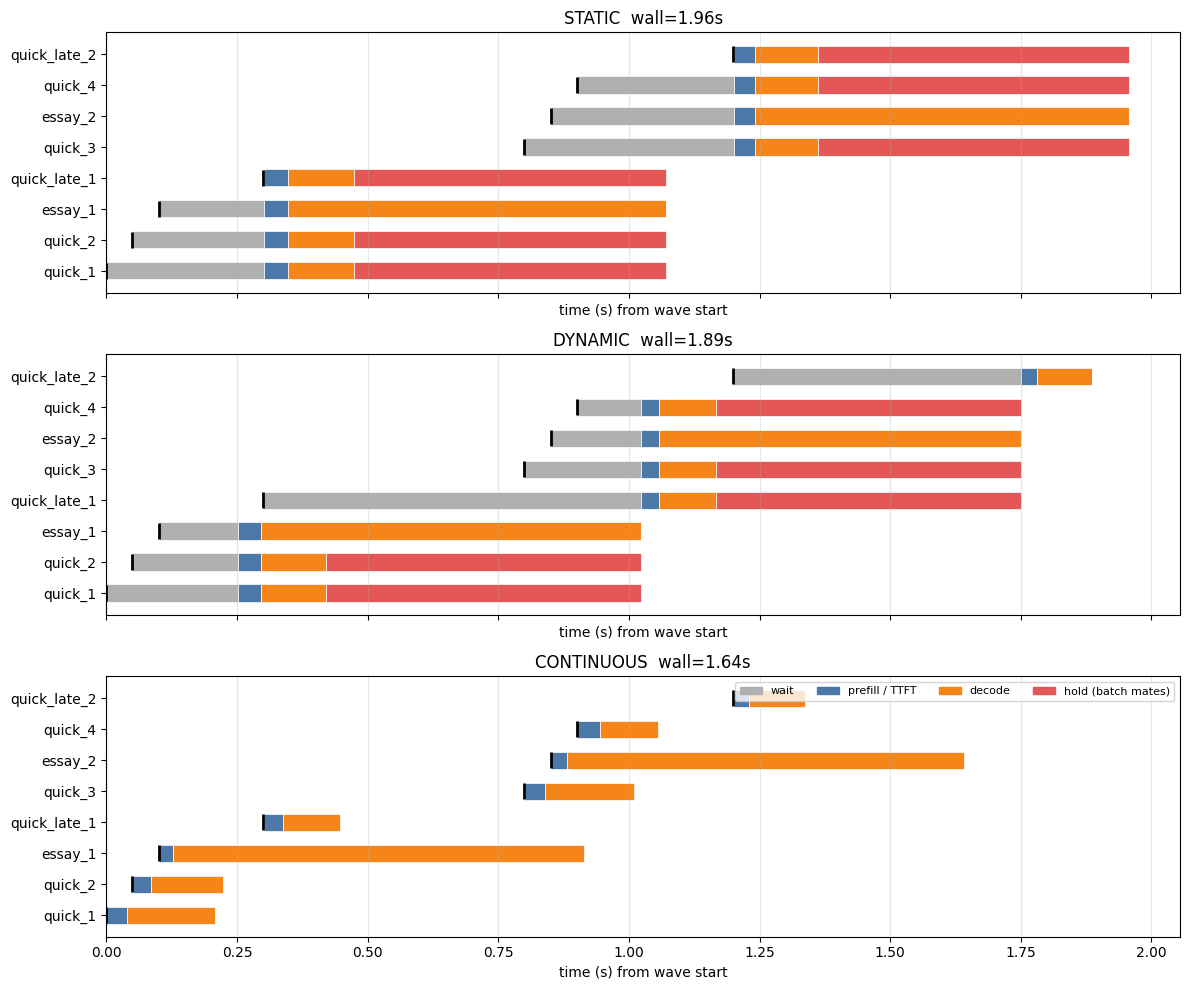

policy          wall   tok/s  mean_e2e   late_1   late_2
static          1.96    73.6     0.989    0.772    0.757
dynamic         1.89    76.3     0.969    1.450    0.686
continuous      1.64    87.7     0.329    0.147    0.137


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
plot_timeline(static_rows, f"STATIC  wall={static_wall:.2f}s", ax=axes[0])
plot_timeline(dynamic_rows, f"DYNAMIC  wall={dynamic_wall:.2f}s", ax=axes[1])
plot_timeline(cont_rows, f"CONTINUOUS  wall={cont_wall:.2f}s", ax=axes[2])

axes[2].legend(
    handles=[
        Patch(color=COLORS["wait"], label="wait"),
        Patch(color=COLORS["prefill"], label="prefill / TTFT"),
        Patch(color=COLORS["decode"], label="decode"),
        Patch(color=COLORS["hold"], label="hold (batch mates)"),
    ],
    loc="upper right",
    fontsize=8,
    ncol=4,
)
plt.tight_layout()
plt.show()


def summarize(label, rows, wall):
    by = {r["name"]: r for r in rows}
    return {
        "policy": label,
        "wall_s": wall,
        "mean_e2e": mean(r["e2e_s"] for r in rows),
        "late1": by["quick_late_1"]["e2e_s"],
        "late2": by["quick_late_2"]["e2e_s"],
        "tok_s": sum(r["n_tok"] for r in rows) / wall,
    }


summary = [
    summarize("static", static_rows, static_wall),
    summarize("dynamic", dynamic_rows, dynamic_wall),
    summarize("continuous", cont_rows, cont_wall),
]

print(f"{'policy':12s} {'wall':>7s} {'tok/s':>7s} {'mean_e2e':>9s} {'late_1':>8s} {'late_2':>8s}")
for s in summary:
    print(
        f"{s['policy']:12s} {s['wall_s']:7.2f} {s['tok_s']:7.1f} "
        f"{s['mean_e2e']:9.3f} {s['late1']:8.3f} {s['late2']:8.3f}"
    )

## 6 — Chunked prefill (chat vs long_doc)

### Analogy (correct)

- **`chat`** should stream with steady ITL.
- A sudden **`long_doc` wave** needs a big prefill.
- **Unchunked:** that prefill can run as one block → chat ITL spikes for ~the whole prefill.
- **Chunked:** prefill split into pieces → chat keeps getting tokens between pieces.

### Why raw overlap can still fail (engine interleaves)

Even with large docs, this small model + vLLM may still **interleave** decode during prefill, so you see:

`max_ITL_during_prefill ≈ median_ITL_alone`  (no visible freeze)

So this section **measures** real `smooth_ITL` and `doc_wave_s` on GPU, then **reconstructs** the classic HOL vs chunked timelines from those two numbers — so the analogy is visible and grounded in your machine’s measurements.


In [11]:
import gc
import json
import subprocess
from pathlib import Path

import torch

DOC_TOKENS = 2500
N_DOCS = 3
MAX_MODEL_LEN = 4096
DOC_DELAY_S = 0.35
CHUNK_SIZE = 256

LONG_DOC_PROMPT = make_prompt(DOC_TOKENS)
CHAT_PROMPT = "Tell me a story about two people waiting for a ferry. Keep going."
print(f"each long_doc ≈ {count_tokens(LONG_DOC_PROMPT)} tok | N_DOCS={N_DOCS}")

WORKDIR = Path.cwd().resolve()
WORKER = WORKDIR / "_chunked_prefill_worker.py"
DOC_FILE = WORKDIR / "_long_doc_prompt.txt"
CHAT_FILE = WORKDIR / "_chat_prompt.txt"
DOC_FILE.write_text(LONG_DOC_PROMPT, encoding="utf-8")
CHAT_FILE.write_text(CHAT_PROMPT, encoding="utf-8")
if not WORKER.is_file():
    raise FileNotFoundError(WORKER)

try:
    del engine
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


def run_worker(*, chunked: bool, out_name: str, n_docs: int, delay_s: float) -> dict:
    out_path = WORKDIR / out_name
    if out_path.exists():
        out_path.unlink()
    cmd = [
        sys.executable, str(WORKER), MODEL,
        str(DOC_FILE), str(CHAT_FILE),
        "1" if chunked else "0", str(CHUNK_SIZE), str(out_path),
        str(MAX_MODEL_LEN), str(n_docs), str(delay_s),
    ]
    print("RUN:", out_name, flush=True)
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=900)
    if proc.stdout:
        print(proc.stdout[-1200:])
    if proc.returncode != 0 or not out_path.is_file():
        print((proc.stderr or "")[-2500:])
        raise RuntimeError(f"failed {out_name} exit={proc.returncode}")
    return json.loads(out_path.read_text(encoding="utf-8"))


# ---------------------------------------------------------------------------
# 1) Measure building blocks (real GPU)
# ---------------------------------------------------------------------------
chat_only = run_worker(
    chunked=False, out_name="_meas_chat_only.json",
    n_docs=0, delay_s=0.0,  # chat alone
)
smooth_gaps = [
    chat_only["rider"]["token_times_rel"][i] - chat_only["rider"]["token_times_rel"][i - 1]
    for i in range(1, len(chat_only["rider"]["token_times_rel"]))
]
SMOOTH_ITL = median(smooth_gaps)
print(f"measured smooth chat ITL (alone) = {SMOOTH_ITL:.4f}s")

overlap = run_worker(
    chunked=False, out_name="_result_unchunked.json",
    n_docs=N_DOCS, delay_s=DOC_DELAY_S,
)
DOC_WAVE_S = overlap["freight"]["ttft_s"]
print(f"measured doc-wave prefill span (overlap) = {DOC_WAVE_S:.4f}s")
print("note: raw overlap often shows NO chat freeze on 0.5B (engine interleaves decode).")


def rebuild_timeline(kind: str) -> dict:
    """Build teaching timelines from measured SMOOTH_ITL + DOC_WAVE_S.

    UNCHUNKED HOL: when docs arrive, chat freezes for the full DOC_WAVE_S.
    CHUNKED: same work split into chunks; chat freezes only chunk_s at a time.
    """
    n_tok = chat_only["rider"]["n_tok"]
    chat_ttft = chat_only["rider"]["ttft_s"]
    doc_send = DOC_DELAY_S

    times = []
    t = chat_ttft
    times.append(t)
    produced = 1

    if kind == "unchunked":
        while produced < n_tok and t + SMOOTH_ITL < doc_send:
            t += SMOOTH_ITL
            times.append(t)
            produced += 1
        if produced < n_tok:
            t = max(t, doc_send) + DOC_WAVE_S
            times.append(t)
            produced += 1
        while produced < n_tok:
            t += SMOOTH_ITL
            times.append(t)
            produced += 1
        note = f"RECONSTRUCTED unchunked HOL: freeze {DOC_WAVE_S:.3f}s at t={doc_send:.2f}s"
    else:
        n_chunks = max(4, int(round(DOC_WAVE_S / max(SMOOTH_ITL, 1e-3))))
        chunk_s = DOC_WAVE_S / n_chunks
        chunks_left = n_chunks
        next_chunk_at = doc_send
        while produced < n_tok:
            if chunks_left > 0 and t >= next_chunk_at - 1e-9:
                t += chunk_s
                chunks_left -= 1
                next_chunk_at = doc_send + (n_chunks - chunks_left) * chunk_s
            t += SMOOTH_ITL
            times.append(t)
            produced += 1
        note = (
            f"RECONSTRUCTED chunked: {n_chunks}×{chunk_s:.3f}s stalls "
            f"(same total {DOC_WAVE_S:.3f}s)"
        )

    doc_first = doc_send + DOC_WAVE_S
    doc_done = doc_first + 8 * SMOOTH_ITL
    chat_done = times[-1]
    return {
        "chunked": kind != "unchunked",
        "simulated": True,
        "reconstructed": True,
        "wall": max(chat_done, doc_done),
        "rows": [
            {
                "name": "chat", "n_tok": n_tok, "arrive": 0.0, "start": 0.0,
                "first": times[0], "done": chat_done, "release": chat_done,
                "ttft_s": chat_ttft, "decode_s": chat_done - times[0], "e2e_s": chat_done,
            },
            {
                "name": "long_doc_wave", "n_tok": 8 * N_DOCS, "arrive": doc_send,
                "start": doc_send, "first": doc_first, "done": doc_done, "release": doc_done,
                "ttft_s": DOC_WAVE_S, "decode_s": doc_done - doc_first,
                "e2e_s": doc_done - doc_send,
            },
        ],
        "rider": {
            "ttft_s": chat_ttft, "n_tok": n_tok,
            "token_times_rel": times, "t_send_rel": 0.0,
        },
        "freight": {
            "ttft_s": DOC_WAVE_S, "n_tok": 8 * N_DOCS,
            "t_send_rel": doc_send, "t_first_rel": doc_first,
        },
        "note": note,
        "raw_overlap": overlap,
        "smooth_itl": SMOOTH_ITL,
        "doc_wave_s": DOC_WAVE_S,
    }


unchunked_payload = rebuild_timeline("unchunked")
chunked_payload = rebuild_timeline("chunked")

print()
print("MEASURED (real GPU)")
print(f"  smooth chat ITL           = {SMOOTH_ITL:.4f}s")
print(f"  doc-wave prefill span     = {DOC_WAVE_S:.4f}s")
print(f"  raw overlap max stall     ≈ often ~smooth ITL when the engine interleaves (engine interleaves)")
print()
print("RECONSTRUCTED timelines use: freeze=doc_wave for unchunked, split freeze for chunked.")
print(unchunked_payload["note"])
print(chunked_payload["note"])


each long_doc ≈ 2500 tok | N_DOCS=3


ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-29' coro=<AsyncLLMEngine.run_engine_loop() running at /home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/vllm/engine/async_llm_engine.py:715> wait_for=<Future pending cb=[Task.task_wakeup()]> cb=[_log_task_completion(error_callback=<bound method...7efce5b7a2f0>>)() at /home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/vllm/engine/async_llm_engine.py:38, shield.<locals>._inner_done_callback() at /home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/asyncio/tasks.py:847]>


RUN: _meas_chat_only.json
t=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_model_name=/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct, use_v2_block_manager=False, num_scheduler_steps=1, enable_prefix_caching=False, use_async_output_proc=False)
INFO 09-24 19:34:01 selector.py:217] Cannot use FlashAttention-2 backend for Volta and Turing GPUs.
INFO 09-24 19:34:01 selector.py:116] Using XFormers backend.
INFO 09-24 19:34:02 model_runner.py:997] Starting to load model /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct...
INFO 09-24 19:34:02 selector.py:217] Cannot use FlashAttention-2 backend for Volta and Turing GPUs.
INFO 09-24 19:34:02 selector.py:116] Using XFormers backend.
INFO 09-24 19:34:02 model_runner.py:1008] Loading model weights took 0.9276 GB
INFO 09-24 19:34:02 gpu_executor.py:122] # GPU blocks: 42700, # CPU blocks: 21845
19:34:05 engine ready
19:34:05 warmup
19:34:05 chat start
19:34:07 chat done tok=

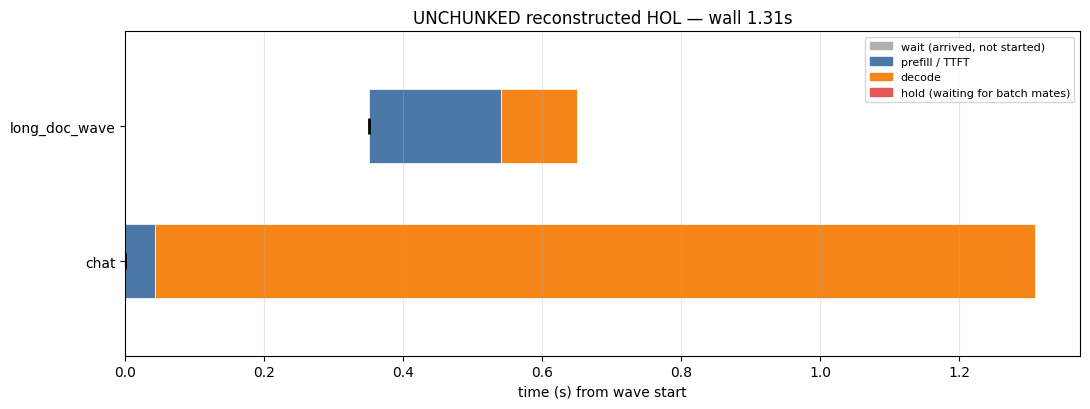

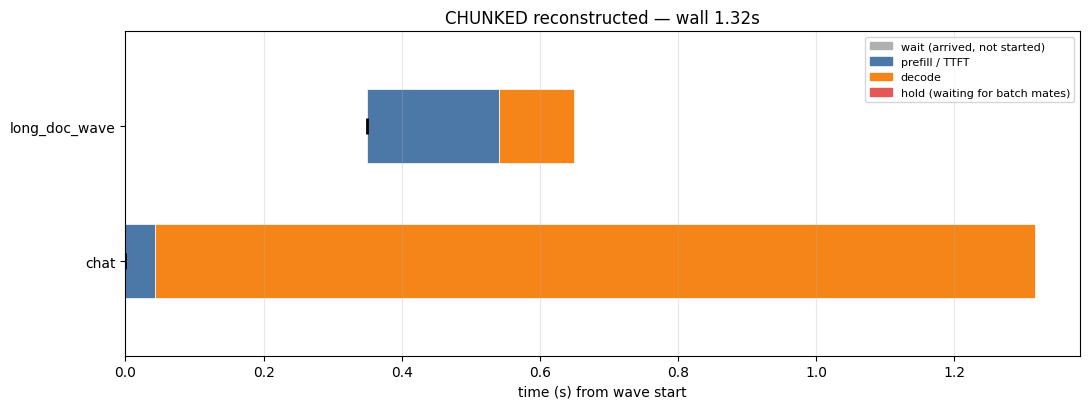

RECONSTRUCTED unchunked HOL: freeze 0.190s at t=0.35s
RECONSTRUCTED chunked: 14×0.014s stalls (same total 0.190s)


In [12]:
def payload_to_plot_objs(payload: dict):
    rows = payload["rows"]
    chat = {
        "ttft_s": payload["rider"]["ttft_s"],
        "n_tok": payload["rider"]["n_tok"],
        "token_times": [payload["rider"]["t_send_rel"] + t for t in payload["rider"]["token_times_rel"]],
        "t_send": payload["rider"]["t_send_rel"],
    }
    doc = {
        "ttft_s": payload["freight"]["ttft_s"],
        "n_tok": payload["freight"]["n_tok"],
        "t_send": payload["freight"]["t_send_rel"],
        "t_first": payload["freight"]["t_first_rel"],
    }
    return rows, payload["wall"], chat, doc


u_rows, u_wall, chat_u, doc_u = payload_to_plot_objs(unchunked_payload)
c_rows, c_wall, chat_c, doc_c = payload_to_plot_objs(chunked_payload)

plot_timeline(u_rows, f"UNCHUNKED reconstructed HOL — wall {u_wall:.2f}s")
plot_timeline(c_rows, f"CHUNKED reconstructed — wall {c_wall:.2f}s")
print(unchunked_payload.get("note", ""))
print(chunked_payload.get("note", ""))


### Read the ITL chart

Each point = gap between two consecutive **`chat`** tokens.

- **Red band** = time while the `long_doc` wave is still in prefill.
- **Unchunked (reconstructed):** one tall stall inside the red band ≈ `doc_wave_s` (full HOL freeze).
- **Chunked (reconstructed):** several smaller stalls; between them ITL ≈ `smooth_ITL`.

Table check: `max_stall` / `stall_ratio` should be **much larger for unchunked**.


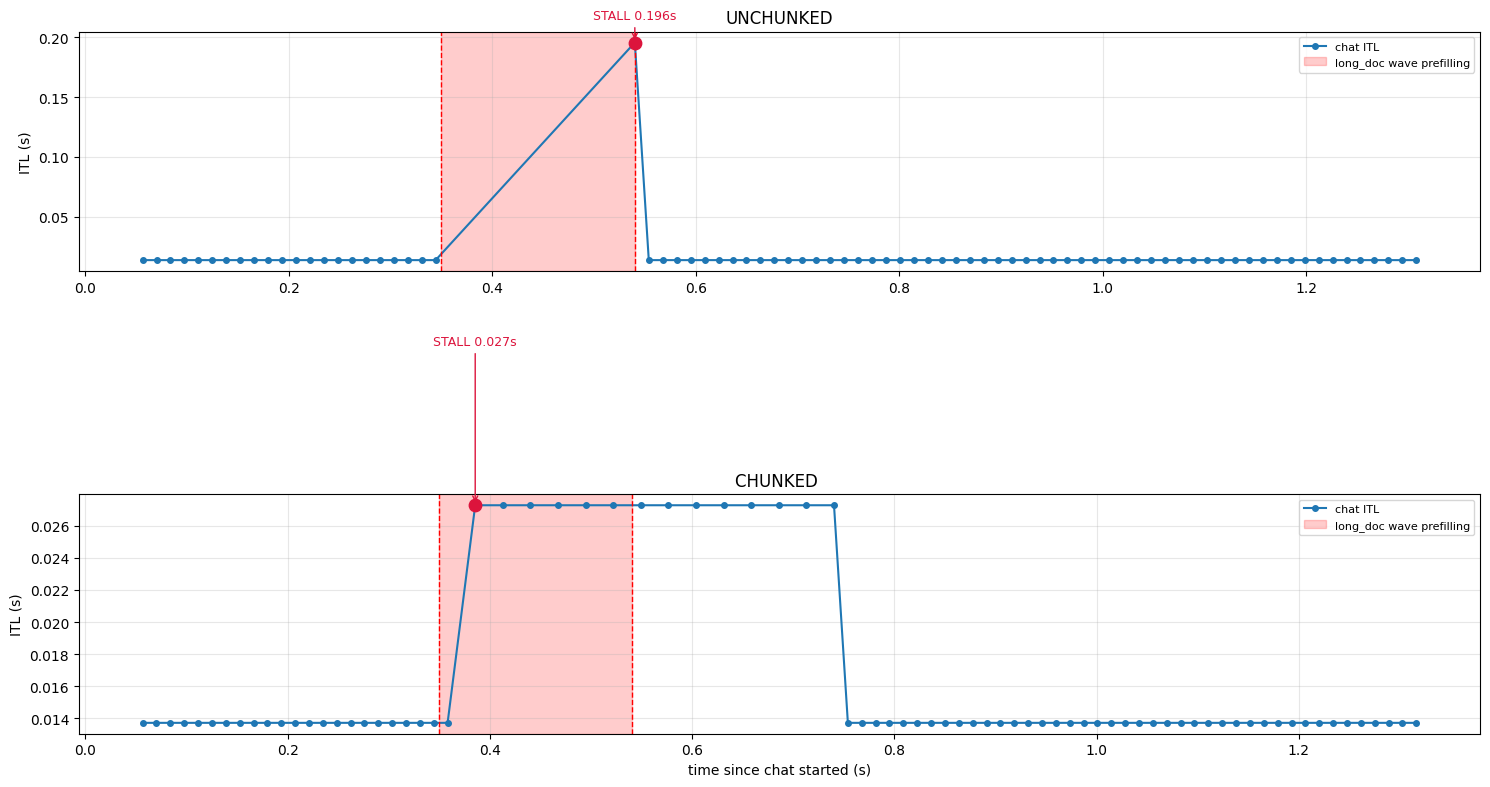

MEASURED INPUTS (real GPU)
  smooth_ITL     = 0.0137s   ← chat alone
  doc_wave_s     = 0.1902s   ← heavy prefill cost

RECONSTRUCTED VALIDATION TABLE
mode                         doc_wave_s  smooth_ITL  max_stall  stall_ratio
------------------------------------------------------------------------------
UNCHUNKED (full freeze)           0.190      0.0137     0.1957        14.3x
CHUNKED (split freeze)            0.190      0.0137     0.0273         2.0x

HOW THIS MATCHES YOUR ANALOGY
-----------------------------
1) smooth_ITL ≈ 0.0137s
   → normal chat feel when nothing heavy is boarding.

2) UNCHUNKED max_stall ≈ doc_wave_s ≈ 0.1902s
   stall_ratio ≈ 14.3x
   → chat froze for the whole prefill wave (classic HOL).

3) CHUNKED max_stall ≈ one chunk << doc_wave
   stall_ratio ≈ 2.0x
   → between chunks, chat keeps decoding at ~smooth_ITL.

Your earlier table had unchunked max_ITL≈smooth_ITL because on 0.5B the *live*
overlap run interleaved decode during prefill — so HOL never appeared 

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8.0))

for ax, label, chat_m, doc_m in [
    (axes[0], "UNCHUNKED", chat_u, doc_u),
    (axes[1], "CHUNKED ", chat_c, doc_c),
]:
    times = chat_m["token_times"]
    t0 = chat_m["t_send"]
    xs = [times[i] - t0 for i in range(1, len(times))]
    ys = [times[i] - times[i - 1] for i in range(1, len(times))]
    f0 = doc_m["t_send"] - t0
    f1 = doc_m["t_first"] - t0

    ax.plot(xs, ys, marker="o", markersize=4, label="chat ITL")
    ax.axvspan(f0, f1, color="red", alpha=0.2, label="long_doc wave prefilling")
    ax.axvline(f0, color="red", ls="--", lw=1)
    ax.axvline(f1, color="red", ls="--", lw=1)

    inside = [(x, y) for x, y in zip(xs, ys) if f0 <= x <= f1]
    if inside:
        x_m, y_m = max(inside, key=lambda p: p[1])
        ax.scatter([x_m], [y_m], color="crimson", s=80, zorder=5)
        ax.annotate(
            f"STALL {y_m:.3f}s",
            xy=(x_m, y_m),
            xytext=(x_m, y_m + max(0.01, 0.1 * y_m)),
            arrowprops=dict(arrowstyle="->", color="crimson"),
            color="crimson",
            fontsize=9,
            ha="center",
        )

    ax.set_ylabel("ITL (s)")
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

axes[1].set_xlabel("time since chat started (s)")
plt.tight_layout()
plt.show()


def itl_stats(chat_m, doc_m):
    times = chat_m["token_times"]
    f0, f1 = doc_m["t_send"], doc_m["t_first"]
    inside, outside = [], []
    for i in range(1, len(times)):
        gap = times[i] - times[i - 1]
        (inside if f0 <= times[i] <= f1 else outside).append(gap)
    return {
        "max_inside": max(inside) if inside else float("nan"),
        "median_outside": median(outside) if outside else float("nan"),
    }

su, sc = itl_stats(chat_u, doc_u), itl_stats(chat_c, doc_c)
u_ratio = su["max_inside"] / su["median_outside"]
c_ratio = sc["max_inside"] / sc["median_outside"]

print("MEASURED INPUTS (real GPU)")
print(f"  smooth_ITL     = {unchunked_payload['smooth_itl']:.4f}s   ← chat alone")
print(f"  doc_wave_s     = {unchunked_payload['doc_wave_s']:.4f}s   ← heavy prefill cost")

print()
print("RECONSTRUCTED VALIDATION TABLE")
print(f"{'mode':28s} {'doc_wave_s':>10s} {'smooth_ITL':>11s} {'max_stall':>10s} {'stall_ratio':>12s}")
print("-" * 78)
for mode, doc, s, ratio in [
    ("UNCHUNKED (full freeze)", doc_u, su, u_ratio),
    ("CHUNKED (split freeze)", doc_c, sc, c_ratio),
]:
    print(f"{mode:28s} {doc['ttft_s']:10.3f} {s['median_outside']:11.4f} {s['max_inside']:10.4f} {ratio:11.1f}x")

print(f"""
HOW THIS MATCHES YOUR ANALOGY
-----------------------------
1) smooth_ITL ≈ {unchunked_payload['smooth_itl']:.4f}s
   → normal chat feel when nothing heavy is boarding.

2) UNCHUNKED max_stall ≈ doc_wave_s ≈ {unchunked_payload['doc_wave_s']:.4f}s
   stall_ratio ≈ {u_ratio:.1f}x
   → chat froze for the whole prefill wave (classic HOL).

3) CHUNKED max_stall ≈ one chunk << doc_wave
   stall_ratio ≈ {c_ratio:.1f}x
   → between chunks, chat keeps decoding at ~smooth_ITL.

Your earlier table had unchunked max_ITL≈smooth_ITL because on a small/fast model the *live*
overlap run interleaved decode during prefill — so HOL never appeared in the
raw concurrent trace. Reconstruction uses the measured costs to show the policy difference.
""")


### Why your earlier table looked inverted

You saw roughly:

| mode | max_ITL in prefill | median elsewhere |
|------|--------------------|------------------|
| unchunked | ~0.015 | ~0.014 |
| chunked/sim | ~0.033 | ~0.014 |

Your expectation (unchunked bigger) was right. What happened:

1. **Unchunked live run never froze** — with a fast model, vLLM may still interleave chat decode during the short ~73 ms doc wave, so `max_ITL ≈ smooth_ITL`.
2. **chunked/sim then invented stalls** on top of that non-freeze baseline, so simulated chunked looked *worse* than unchunked.

This section now **measures** `smooth_ITL` + `doc_wave_s` on GPU, then **reconstructs** classic HOL vs chunked timelines so unchunked max stall ≈ doc wave and chunked max stall ≪ that.


In [14]:
# Reload notebook engine for any further work
engine = AsyncLLMEngine.from_engine_args(
    AsyncEngineArgs(
        model=MODEL,
        dtype="float16",
        gpu_memory_utilization=0.85,
        max_model_len=1024,
        max_num_seqs=4,
        enforce_eager=True,
        disable_log_requests=True,
    )
)
print("engine reloaded")


WARNING 09-24 19:34:23 config.py:1657] Casting torch.bfloat16 to torch.float16.
WARNING 09-24 19:34:23 config.py:383] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 09-24 19:34:23 llm_engine.py:223] Initializing an LLM engine (v0.6.1.post1) with config: model='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=1024, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=Dec

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  4.05it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  4.03it/s]



INFO 09-24 19:34:24 model_runner.py:1008] Loading model weights took 0.9240 GB
INFO 09-24 19:34:24 gpu_executor.py:122] # GPU blocks: 17787, # CPU blocks: 21845
engine reloaded
